noise1: 152.96438974267477 pF pm 1.0108510656202512 pF


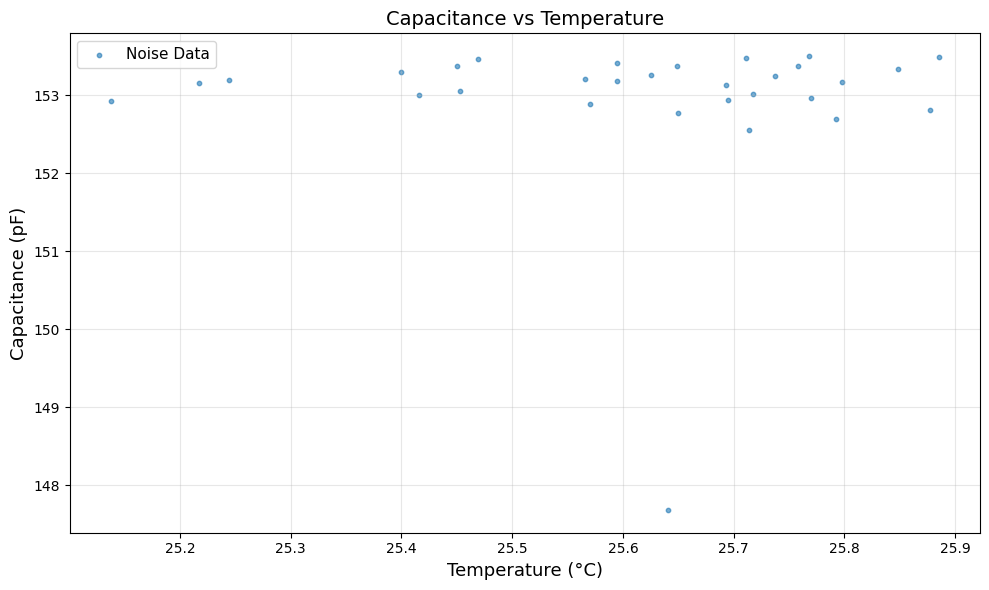

noise2: 151.9161678553883 pF pm 2.380518768201412 pF


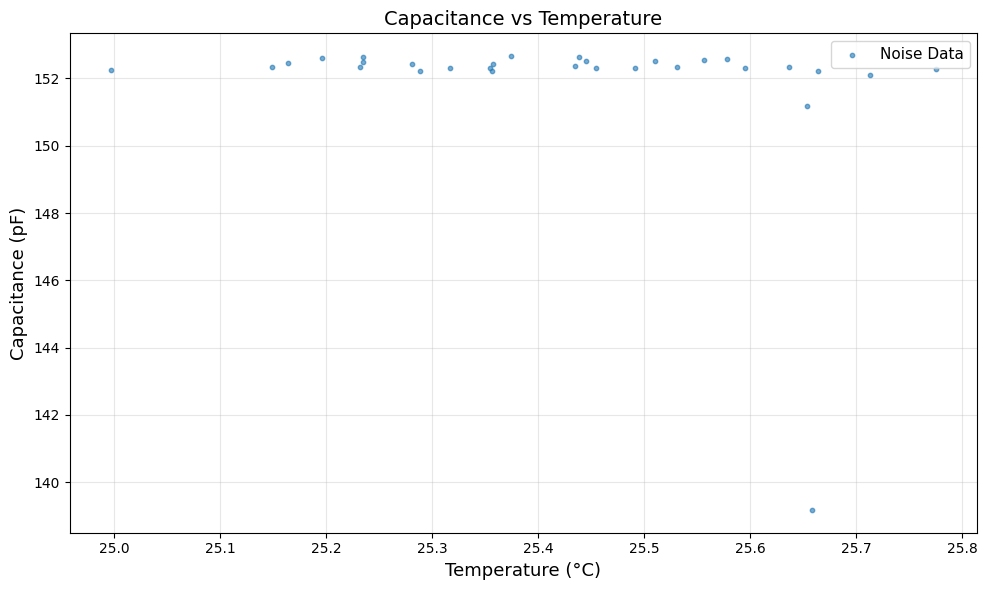

noise3: 153.3112625385612 pF pm 3.153118876271527 pF


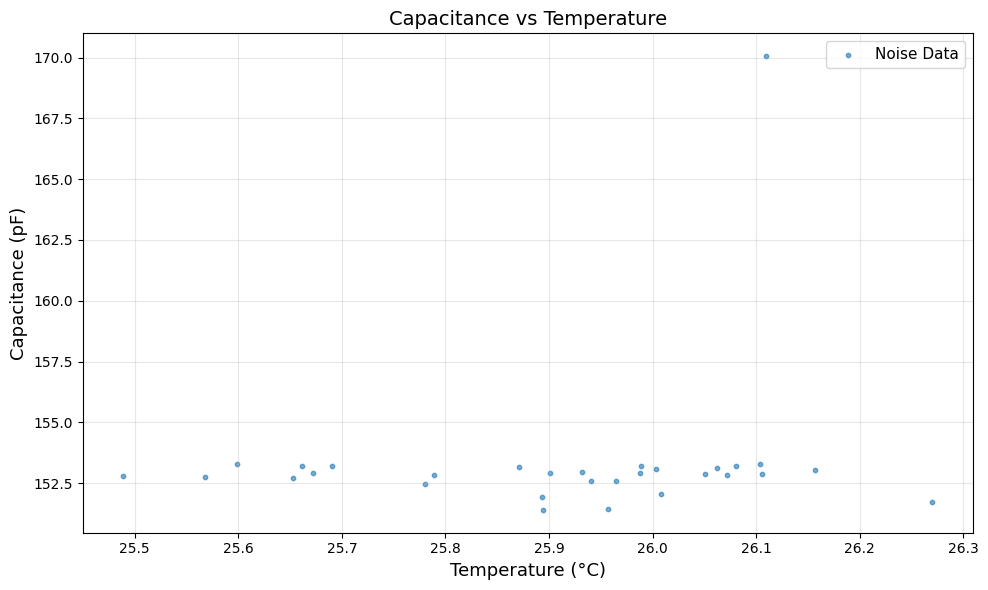

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_FILES = ['noise_data/noise1.csv', 'noise_data/noise2.csv', 'noise_data/noise3.csv']

def plot_noise(filelist):

    i=1
    for csvf in filelist:
        fig, ax = plt.subplots(figsize=(10, 6))
        df = pd.read_csv(csvf)
        ax.scatter(df['temperature_C'], df['capacitance_value'] * 10 ** 12, s=10, alpha=0.6, label='Noise Data')
        cap_mean, cap_std = np.mean(df['capacitance_value']) * 10 ** 12, np.std(df['capacitance_value']) * 10 ** 12
        print(f"noise{i}: {cap_mean} pF pm {cap_std} pF")

        ax.set_xlabel('Temperature (°C)', fontsize=13)
        ax.set_ylabel('Capacitance (pF)', fontsize=13)
        ax.set_title('Capacitance vs Temperature', fontsize=14)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        i+=1
        plt.show()
    return None

plot_noise(CSV_FILES)

noise1: 97.63209985968027 pF pm 0.5099315607109596 pF


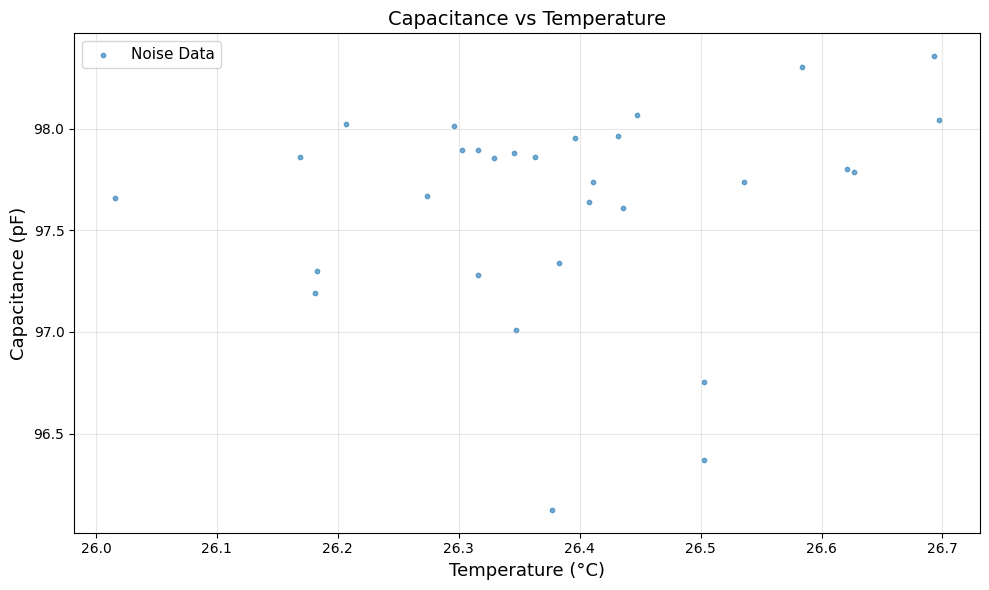

noise2: 74.20907382619978 pF pm 38.11839498228576 pF


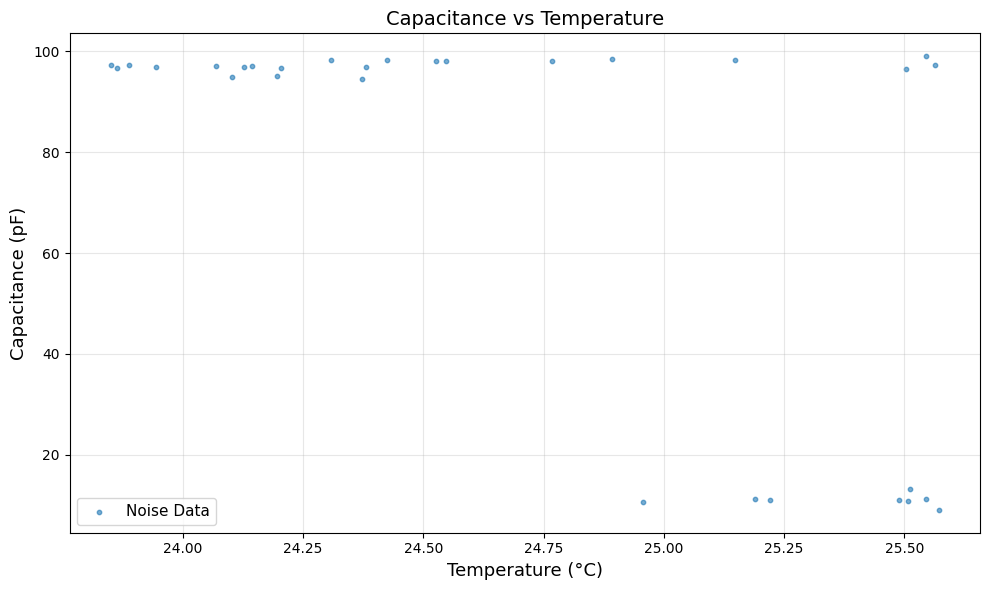

noise3: 96.91184384116526 pF pm 0.4411627106183867 pF


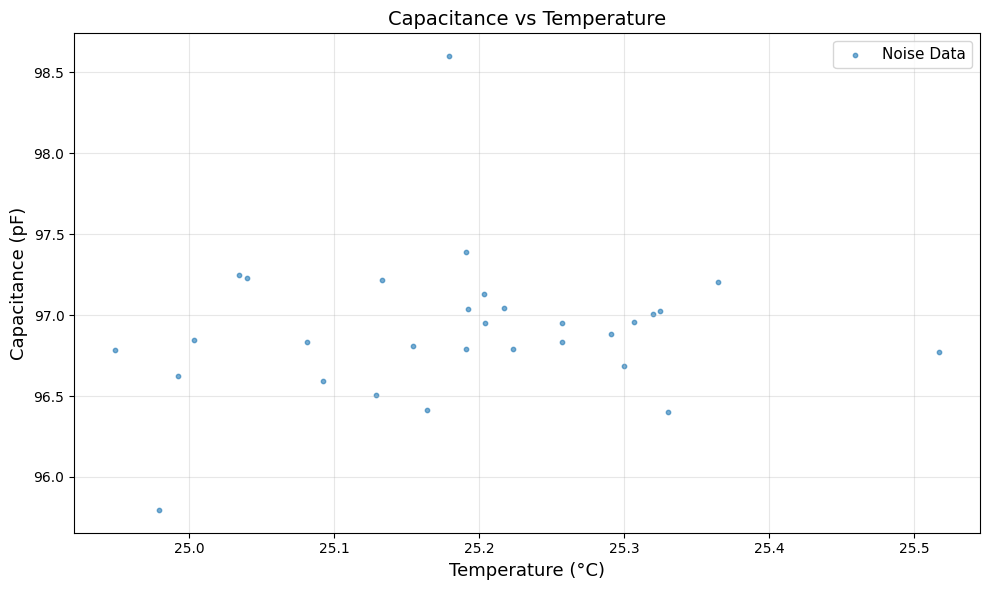

In [45]:
CSV_FILES_SAMPLE = ['noise_data/noise1_sample.csv', 'noise_data/noise2_sample.csv', 'noise_data/noise3_sample.csv']

plot_noise(CSV_FILES_SAMPLE)

noise1: 126.71177472892244 pF pm 0.8038313596598489 pF


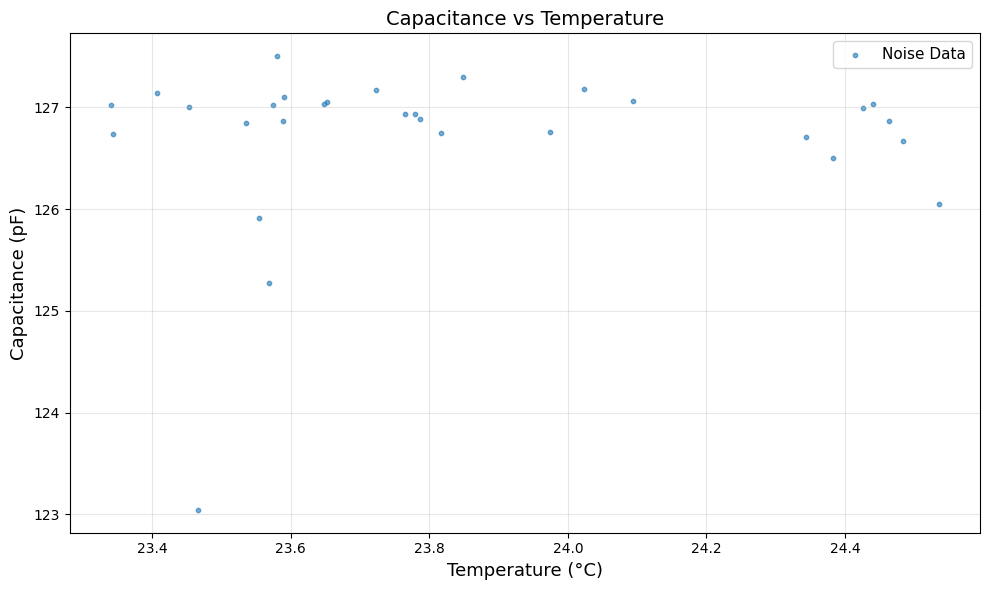

noise2: 127.02647497697198 pF pm 0.3451550742779376 pF


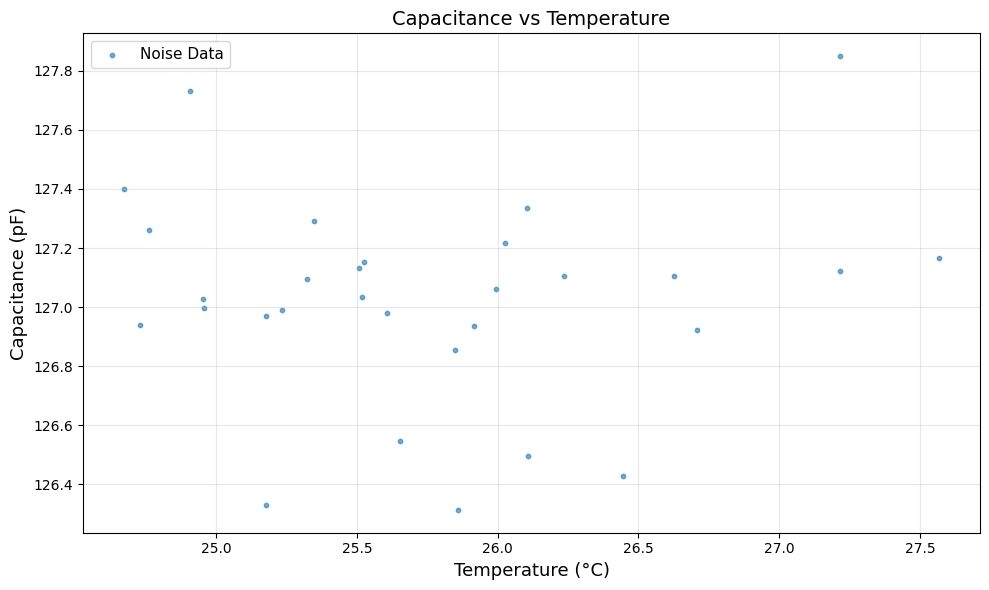

noise3: 126.67387650106376 pF pm 1.3873469950385238 pF


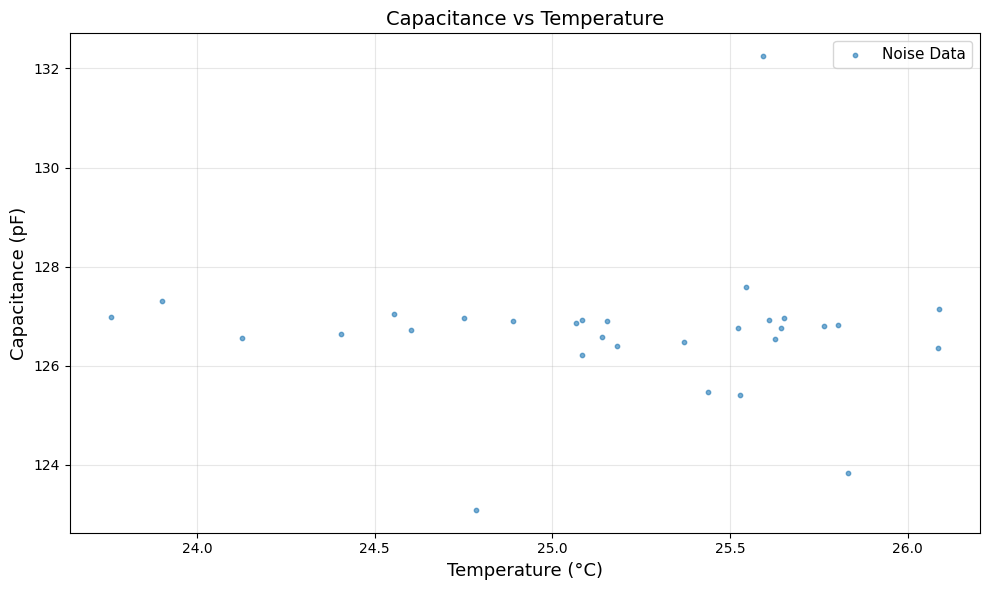

In [46]:
CSV_FILES_SAMPLE_CUT = ['noise_data/noise1_sample_cut.csv', 'noise_data/noise2_sample_cut.csv', 'noise_data/noise3_sample_cut.csv']

plot_noise(CSV_FILES_SAMPLE_CUT)

**Combined Measurements**

In [66]:
def tot_noise_stat(filelist, data_name):
    all_data = []
    weighted_means = 0
    weighting_sum = 0
    for csvf in filelist:
        df = pd.read_csv(csvf)
        good_data = df.loc[df['capacitance_value'] >= 1e-12, 'capacitance_value']
        all_data.extend(good_data.tolist())
        weighting = len(good_data) / np.var(good_data)
        weighting_sum += weighting
        weighted_means += weighting * np.mean(df['capacitance_value'])
    all_data_std = np.std(all_data) * 10 ** 12
    print(f"{data_name}: \nNoise std = {all_data_std} pF \nData range = {(np.max(all_data)-np.min(all_data)) * 10 ** 12} pF\n--------------")
    print(f"{data_name} combined results (room temp capacitance): \nC = ({(weighted_means / weighting_sum) * 10 ** 12} \u00B1 {np.sqrt(1 / weighting_sum) * 10 ** 12}) pF \n")
    return None

tot_noise_stat(CSV_FILES, 'No Sample Runs')
tot_noise_stat(CSV_FILES_SAMPLE, 'Sample Runs')
tot_noise_stat(CSV_FILES_SAMPLE_CUT, 'Cut Sample Runs')
    

No Sample Runs: 
Noise std = 2.4280290001037534 pF 
Data range = 30.893657091723828 pF
--------------
No Sample Runs combined results (room temp capacitance): 
C = (152.8448663144364 ± 0.16292877410097148) pF 

Sample Runs: 
Noise std = 24.551471456078914 pF 
Data range = 90.04684277073015 pF
--------------
Sample Runs combined results (room temp capacitance): 
C = (97.21840192016252 ± 0.06091055661462863) pF 

Cut Sample Runs: 
Noise std = 0.9600245310033966 pF 
Data range = 9.208547180458273 pF
--------------
Cut Sample Runs combined results (room temp capacitance): 
C = (126.96240644218085 ± 0.05644789451409418) pF 

